In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [9]:
df=pd.read_csv("1000_Companies.csv")

In [10]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Create Method To Check The Values In the Data Output DataFrame With The Info

In [11]:
def check_values(df):
    data = []
    for col in df.columns:
        data.append([col,
                     df[col].dtype,
                     df[col].isna().sum(),
                     round(100*(df[col].isna().sum()/len(df)),2),
                     df[col].nunique()
                     ])
    return pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique'],data=data)

In [12]:
check_values(df)

,dataFeatures,dataType,null,nullPct,unique
0,R&D Spend,float64,0,0.0,997
1,Administration,float64,0,0.0,998
2,Marketing Spend,float64,0,0.0,996
3,State,object,0,0.0,3
4,Profit,float64,0,0.0,998


In [ ]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,81668.927200,122963.897612,226205.058419,119546.164656
std,46537.567891,12613.927535,91578.393542,42888.633848
min,0.000000,51283.140000,0.000000,14681.400000
25%,43084.500000,116640.684850,150969.584600,85943.198543
50%,79936.000000,122421.612150,224517.887350,117641.466300
75%,124565.500000,129139.118000,308189.808525,155577.107425
max,165349.200000,321652.140000,471784.100000,476485.430000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        1000 non-null   float64
 1   Administration   1000 non-null   float64
 2   Marketing Spend  1000 non-null   float64
 3   State            1000 non-null   object 
 4   Profit           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [16]:
df.shape

(1000, 5)

In [17]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


First Of All We Optain The Correlation Between The Numerical Columns In The Data

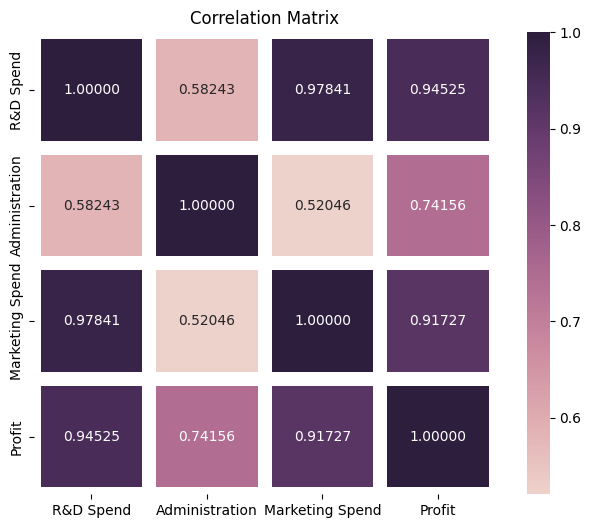

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap=sns.cubehelix_palette(as_cmap=True),annot=True,square=True, linewidths=10,linecolor='white',fmt=".5f")
plt.title("Correlation Matrix")
plt.show()

In [18]:
df[df['Profit'] == df['Profit'].max()]

,R&D Spend,Administration,Marketing Spend,State,Profit
999,161181.72,270939.86,295442.17,New York,476485.43


In [19]:
df[df['Profit'] == df['Profit'].min()]

,R&D Spend,Administration,Marketing Spend,State,Profit
49,0.0,116983.8,45173.06,California,14681.4


In [20]:
df.sample(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
873,105205.00,125994.2492,271772.3740,Florida,138908.6228
513,104830.00,125938.8675,271048.8105,New York,138588.2636
626,122931.00,128612.1056,305974.7394,New York,154051.7917
341,136849.00,130667.5793,332829.5584,New York,165941.8190
15,114523.61,122616.8400,261776.2300,New York,129917.0400


# here we want to know minimmum Spend in Administration, R&D, Marketing Makes How Much Profit TO know What Is the most Important Spend Affects On the Profit

In [21]:
df[df['Administration'] == df['Administration'].min()]

,R&D Spend,Administration,Marketing Spend,State,Profit
37,44069.95,51283.14,197029.42,California,89949.14


In [22]:
df[df['Marketing Spend'] == df['Marketing Spend'].min()]

,R&D Spend,Administration,Marketing Spend,State,Profit
19,86419.70,153514.11,0.0,New York,122776.86
47,0.00,135426.92,0.0,California,42559.73
48,542.05,51743.15,0.0,New York,35673.41


In [24]:
df[df['R&D Spend'] == df['R&D Spend'].min()]

,R&D Spend,Administration,Marketing Spend,State,Profit
47,0.0,135426.92,0.00,California,42559.73
49,0.0,116983.80,45173.06,California,14681.40


Correlation between Marketing Spend And Profit


In [ ]:
df[['Profit','Marketing Spend']].corr()

,Profit,Marketing Spend
Profit,1.00000,0.91727
Marketing Spend,0.91727,1.00000


Correlation between R&D Spend And Profit


In [ ]:
df[['Profit','R&D Spend']].corr()

,Profit,R&D Spend
Profit,1.000000,0.945245
R&D Spend,0.945245,1.000000


Correlation between Administration Spend And Profit


In [ ]:
df[['Profit','Administration']].corr()

,Profit,Administration
Profit,1.00000,0.74156
Administration,0.74156,1.00000


Correlation between R&D And Marketing Spend


In [ ]:
df[['R&D Spend','Marketing Spend']].corr()

,R&D Spend,Marketing Spend
R&D Spend,1.000000,0.978407
Marketing Spend,0.978407,1.000000


#Declare A New Column Called Total_company_spend To know how muhc each company spend in (Administration, R&D, Marketing)

In [28]:
total_company_spend=[]
total_company_spend=df['R&D Spend']+df['Marketing Spend']+df['Administration']
df['Total_company_spend']=total_company_spend
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit,Total_company_spend
0,165349.20,136897.80,471784.10,New York,192261.83,774031.10
1,162597.70,151377.59,443898.53,California,191792.06,757873.82
2,153441.51,101145.55,407934.54,Florida,191050.39,662521.60
3,144372.41,118671.85,383199.62,New York,182901.99,646243.88
4,142107.34,91391.77,366168.42,Florida,166187.94,599667.53


#Relation Between Administration VS Profit

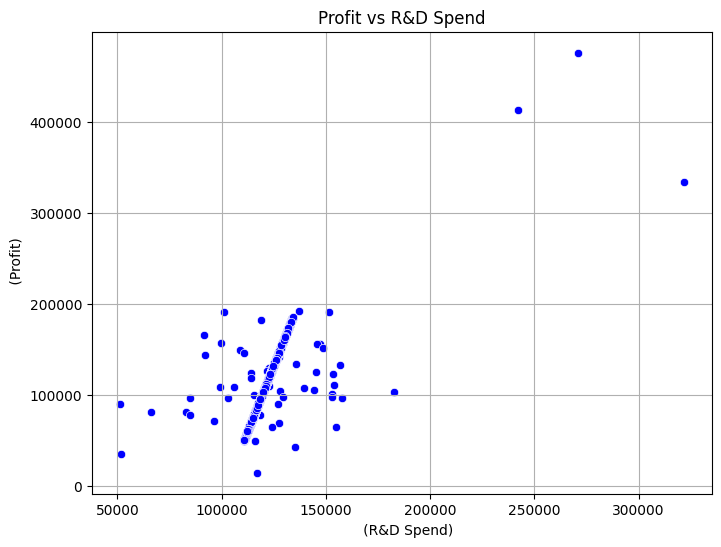

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Administration',y='Profit',color="blue")
plt.title('Profit vs R&D Spend')
plt.xlabel('   (R&D Spend)')
plt.ylabel(' (Profit)')
plt.grid(True)
plt.show()

#Relation Between Marketing Spend VS Profit

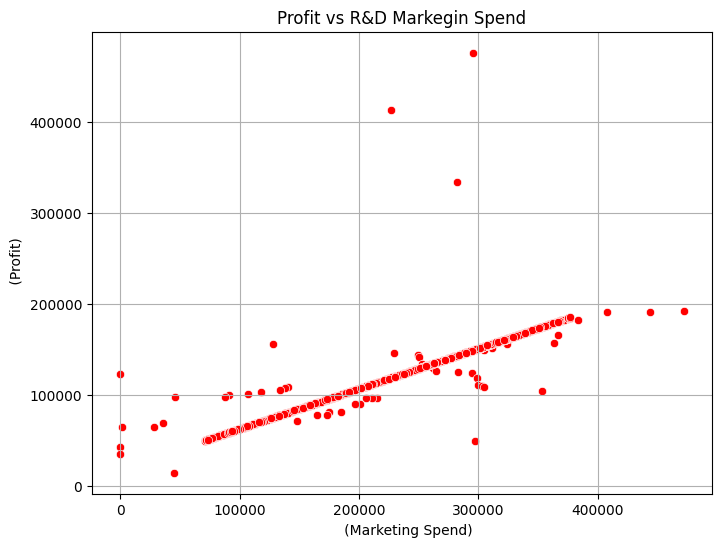

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Marketing Spend',y='Profit',color="red")
plt.title('Profit vs R&D Markegin Spend')
plt.xlabel('   (Marketing Spend)')
plt.ylabel(' (Profit)')
plt.grid(True)
plt.show()

#Relation Between Research & Developement VS Profit

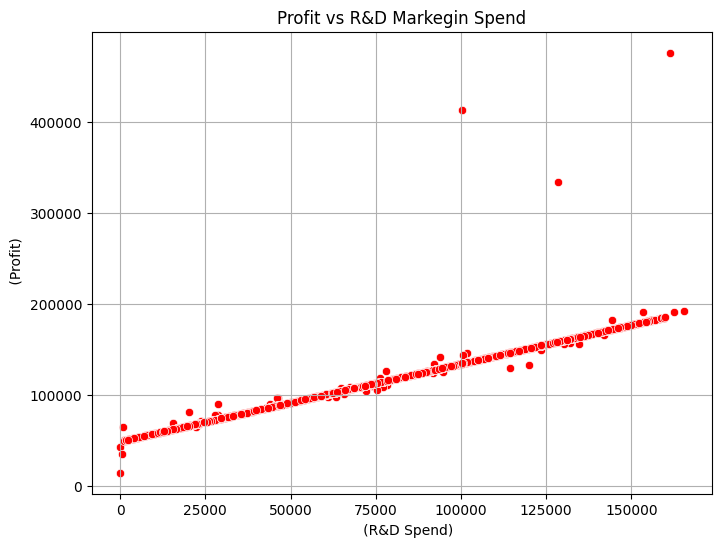

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='R&D Spend',y='Profit',color="red")
plt.title('Profit vs R&D Markegin Spend')
plt.xlabel('   (R&D Spend)')
plt.ylabel(' (Profit)')
plt.grid(True)
plt.show()

#Relation Between Research & Developement VS Profit

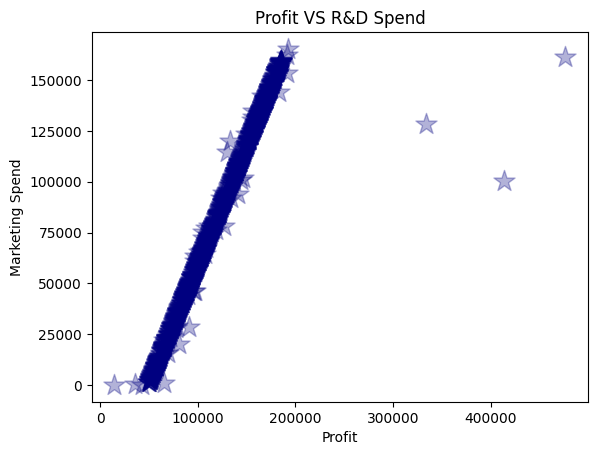

In [ ]:
plt.scatter(df.Profit,df['R&D Spend'],color="navy",marker="*",s=255,alpha=0.3)
plt.title("Profit VS R&D Spend")
plt.xlabel("Profit")
plt.ylabel("Marketing Spend")
plt.show()

In [ ]:
df.groupby('State')['Profit'].sum().sort_values(ascending=False)

,Profit
State,
California,4.106206e+07
New York,3.966478e+07
Florida,3.881932e+07


In [33]:
df.groupby('State')['Marketing Spend'].sum().sort_values(ascending=False)

,Marketing Spend
State,
California,7.703682e+07
New York,7.466773e+07
Florida,7.450050e+07


In [34]:
df.groupby('State')['R&D Spend'].sum().sort_values(ascending=False)

,R&D Spend
State,
California,27796703.16
Florida,26944276.26
New York,26927947.78


In [35]:
df.groupby('State')['Administration'].sum().sort_values(ascending=False)

,Administration
State,
California,4.242386e+07
New York,4.100336e+07
Florida,3.953668e+07


In [36]:
# total (profit,Administration,Marketgin Spend , R&D Spend : california : 4.106206e+07 ,7%on flo 3% on new 4.242386e+07 , 3% on new 7.703682e+07 , 27796703.16 , 3% 1397280.0 new , 5% 2242740.0 florida

                                            #              : New York   : 3.966478e+07 , 4.100336e+07 , 7.466773e+07 , 26944276.26

                                            #              : Florida    : 3.881932e+07 , 3.953668e+07 , 7.450050e+07 , 26927947.78 , 845460.0 with new 2% on new

percentage_diff_Profit= ((4.106206e+07- 3.966478e+07) / 3.966478e+07) * 100
print(percentage_diff_Profit,"% + profit for California than New York")
percentage_diff_Profit= ((4.106206e+07- 3.881932e+07) / 3.881932e+07) * 100
print(percentage_diff_Profit,"% + profit for California than Florida ")



3.5227221731722698 % + profit for California than New York
5.777380953607636 % + profit for California than Florida 


#Marketing Spend Pie chart


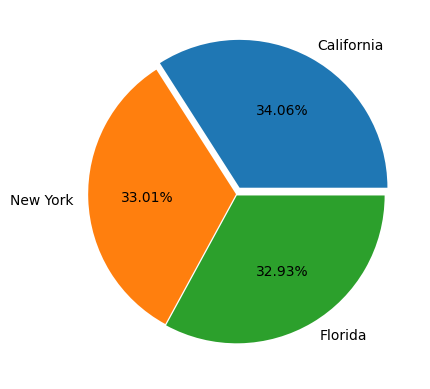

In [ ]:
Stete_label=['California','New York','Florida']
marketings=[7.703682e+07,7.466773e+07,7.450050e+07]
explodes=[0.05,0,0.01]
plt.pie(marketings,labels=Stete_label,autopct="%.2f%%",explode=explodes)
plt.show()

#Total Profit In Each State

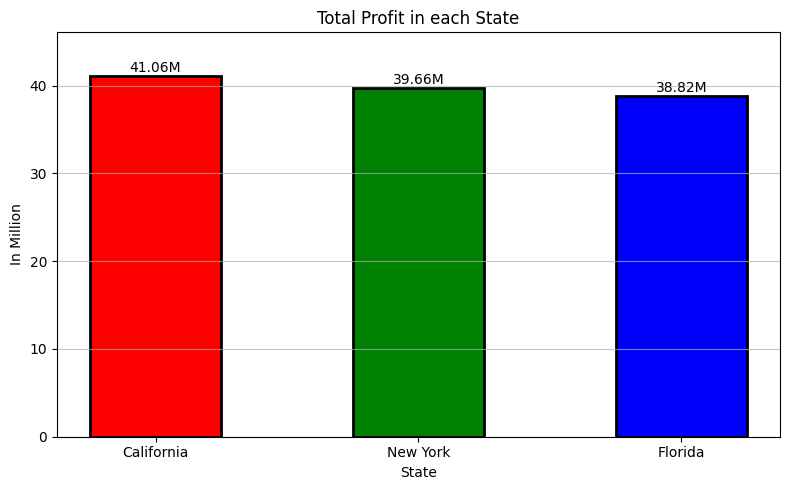

In [ ]:
import matplotlib.pyplot as plt


state_admin_spend = df.groupby("State")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(state_admin_spend.index, state_admin_spend.values / 1e6, color=["red", "green", "blue"],width=0.5,edgecolor='black',lw=2)
plt.title("Total Profit in each State")
plt.xlabel("State")
plt.ylabel("In Million")
plt.ylim(0, max(state_admin_spend.values / 1e6) + 5)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}M", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

#Total Administraion Spend

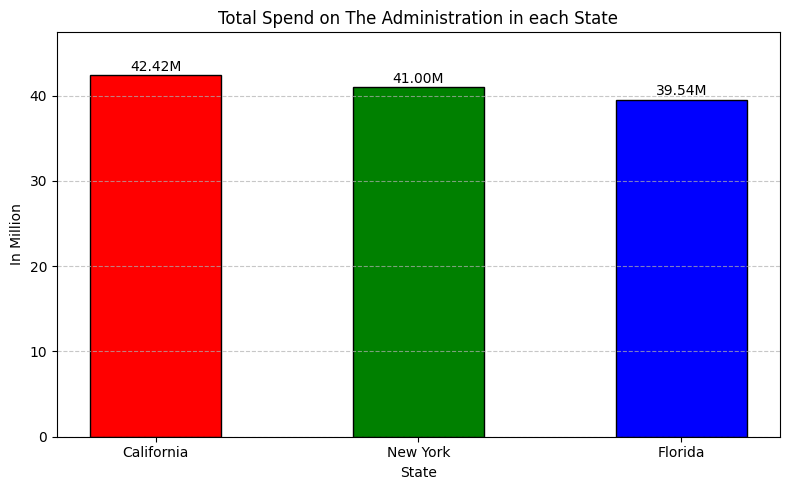

In [30]:

state_admin_spend = df.groupby("State")["Administration"].sum().sort_values(ascending=False)


plt.figure(figsize=(8, 5))
bars = plt.bar(state_admin_spend.index, state_admin_spend.values / 1e6, color=["red", "green", "blue"],edgecolor='black',lw=1,width=0.5)
plt.title("Total Spend on The Administration in each State")
plt.xlabel("State")
plt.ylabel("In Million")
plt.ylim(0, max(state_admin_spend.values / 1e6) + 5)

for bar in bars:
    yvalue = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yvalue + 0.5, f"{yvalue:.2f}M", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Research & Developement Spend visualization

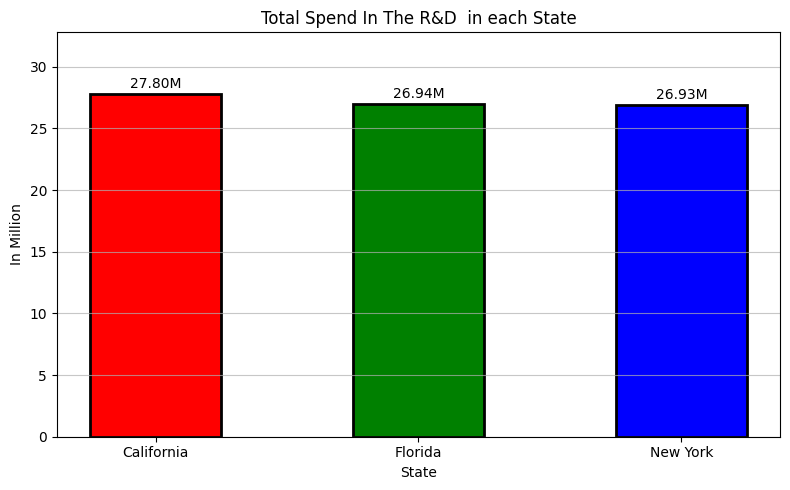

In [ ]:
import matplotlib.pyplot as plt

state_admin_spend = df.groupby("State")["R&D Spend"].sum().sort_values(ascending=False)


plt.figure(figsize=(8, 5))
bars = plt.bar(state_admin_spend.index, state_admin_spend.values / 1e6, color=["red", "green", "blue"],width=0.5,edgecolor='black',lw=2)
plt.title("Total Spend In The R&D  in each State")
plt.xlabel("State")
plt.ylabel("In Million")
plt.ylim(0, max(state_admin_spend.values / 1e6) + 5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}M", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

#Marketing Spend Visualization


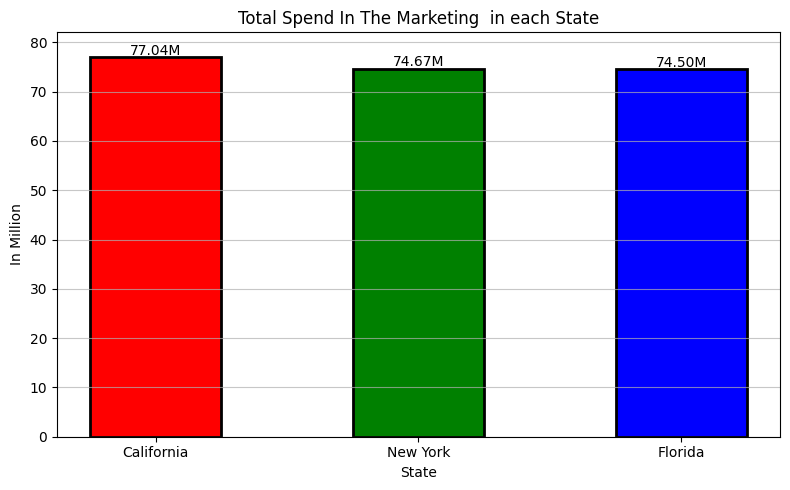

In [ ]:
state_admin_spend = df.groupby("State")["Marketing Spend"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(state_admin_spend.index, state_admin_spend.values / 1e6, color=["red", "green", "blue"],width= 0.5 , edgecolor='black',lw=2)
plt.title("Total Spend In The Marketing  in each State")
plt.xlabel("State")
plt.ylabel("In Million")
plt.ylim(0, max(state_admin_spend.values / 1e6) + 5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}M", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

#Total_Spend Visualization


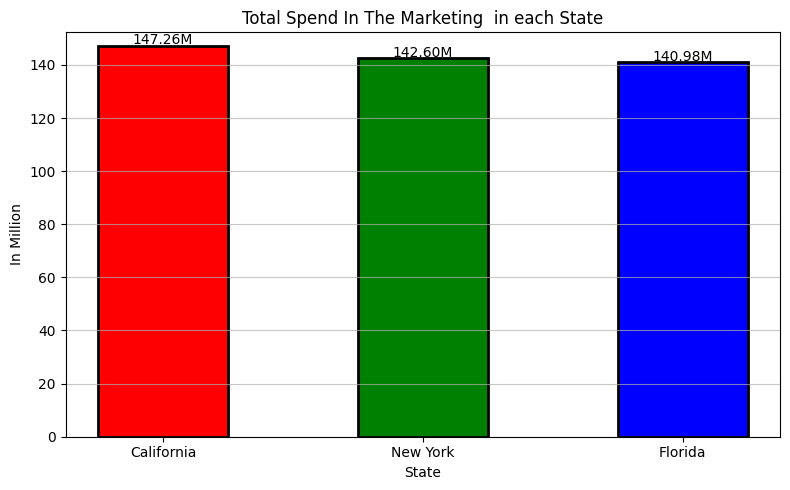

In [29]:
state_admin_spend = df.groupby("State")["Total_company_spend"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(state_admin_spend.index, state_admin_spend.values / 1e6, color=["red", "green", "blue"],width= 0.5 , edgecolor='black',lw=2)
plt.title("Total Spend In The Marketing  in each State")
plt.xlabel("State")
plt.ylabel("In Million")
plt.ylim(0, max(state_admin_spend.values / 1e6) + 5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}M", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

# Correlation Between  Profit , R&D, Marketing Spend

In [ ]:
correlation = df[['R&D Spend', 'Marketing Spend', 'Profit']].corr()
print(correlation)

                 R&D Spend  Marketing Spend    Profit
R&D Spend         1.000000         0.978407  0.945245
Marketing Spend   0.978407         1.000000  0.917270
Profit            0.945245         0.917270  1.000000


# Correlation Between  Profit , R&D, Marketing Spend

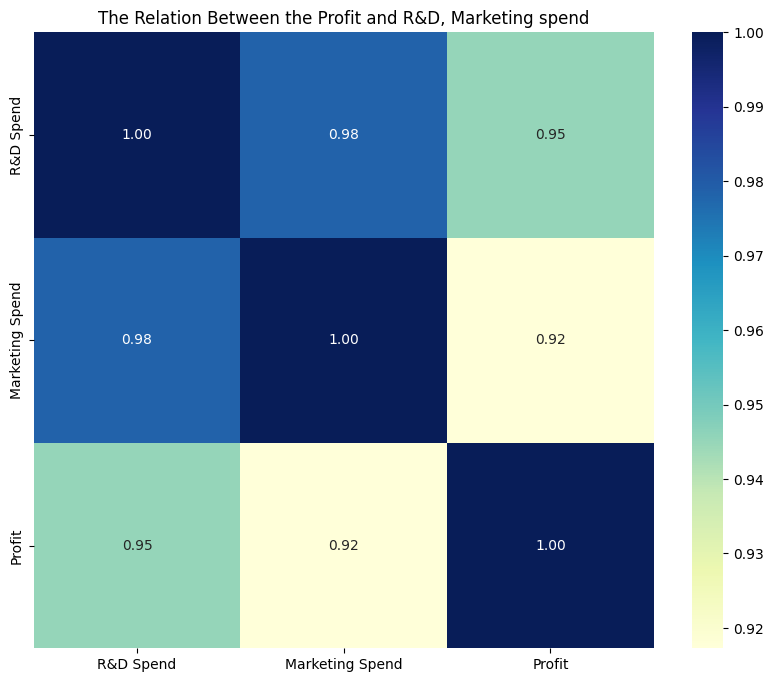

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("The Relation Between the Profit and R&D, Marketing spend")

plt.show()

In [ ]:
df[df['Profit']==df['Profit'].max()]

,R&D Spend,Administration,Marketing Spend,State,Profit
999,161181.72,270939.86,295442.17,New York,476485.43


# * we want to know how many company dont make greater than 100,000 profit to know exactly which way we will spend in R&D, Administration, Marketing

In [37]:
dv = []

for index, row in df.iterrows():
    if row['Profit'] < 90000:
        total_spend = row['Administration'] + row['R&D Spend'] + row['Marketing Spend']
        dv.append({
            'State': row['State'],
            'Total Spend': total_spend,
            'Profit': row['Profit'],
            'Administration':row['Administration'],
            'Marketing spend':row['Marketing Spend'],
            'R&D':row['R&D Spend']
        })

ds = pd.DataFrame(dv)

In [38]:
ds

,State,Total Spend,Profit,Administration,Marketing spend,R&D
0,California,292382.51000,89949.14000,51283.1400,197029.42000,44069.95
1,New York,271442.62000,81229.06000,65947.9300,185265.10000,20229.59
2,California,296539.90000,81005.76000,82982.0900,174999.30000,38558.51
3,California,320096.05000,78239.91000,118546.0500,172795.67000,28754.33
4,Florida,277074.40000,77798.83000,84710.7700,164470.71000,27892.92
...,...,...,...,...,...,...
279,California,218974.93134,60065.21791,112364.2939,93696.63744,12914.00
280,New York,306290.12060,84305.73556,116554.8432,148446.27740,41289.00
281,Florida,302231.31060,83178.92524,116360.0473,145901.26330,39970.00
282,Florida,313192.25170,86221.91110,116886.0996,152774.15210,43532.00


# correlation between Total spend and R&D, Administration, Marketing Spend With Profit

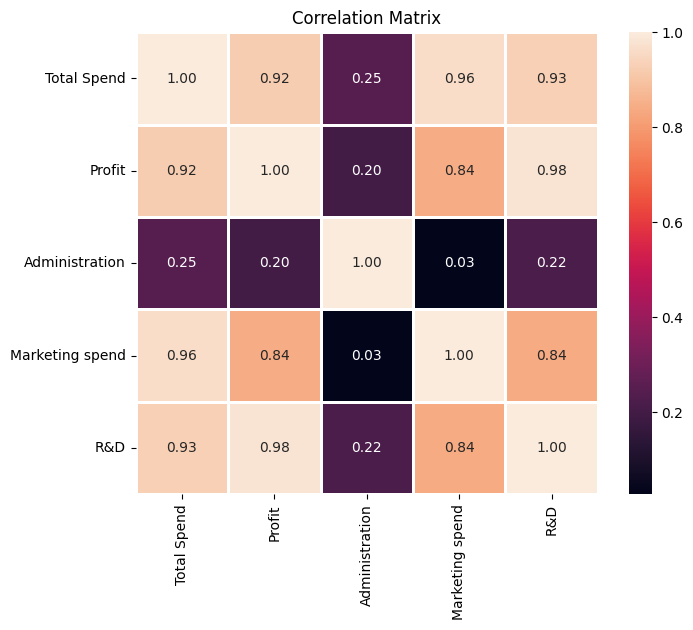

In [ ]:
x=ds.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(x,annot=True,square=True, linewidths=1,linecolor='white',fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# finally the R&D spend is the best way to improve the Profit in those companies


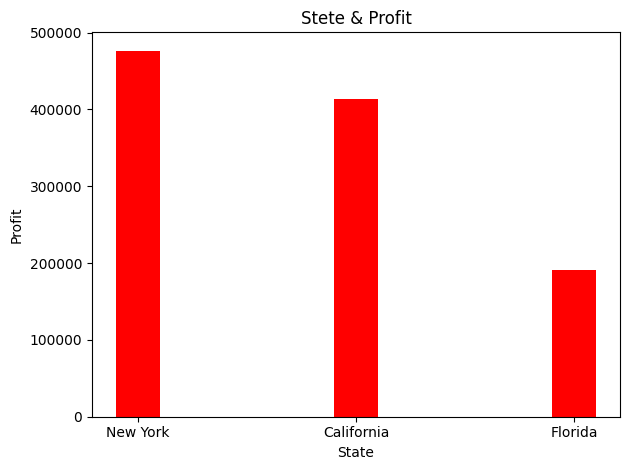

In [ ]:
state_bar=plt.bar(df.State,df.Profit,color="red",width=0.2, align='center')
plt.title("Stete & Profit")
plt.ylabel("Profit")
plt.xlabel("State")
plt.tight_layout()
plt.show()


In [39]:
df[df['Profit']<50000][['Profit','R&D Spend','Administration','Marketing Spend','State',]]

,Profit,R&D Spend,Administration,Marketing Spend,State
46,49490.75,1315.46,115816.21,297114.46,Florida
47,42559.73,0.00,135426.92,0.00,California
48,35673.41,542.05,51743.15,0.00,New York
49,14681.40,0.00,116983.80,45173.06,California


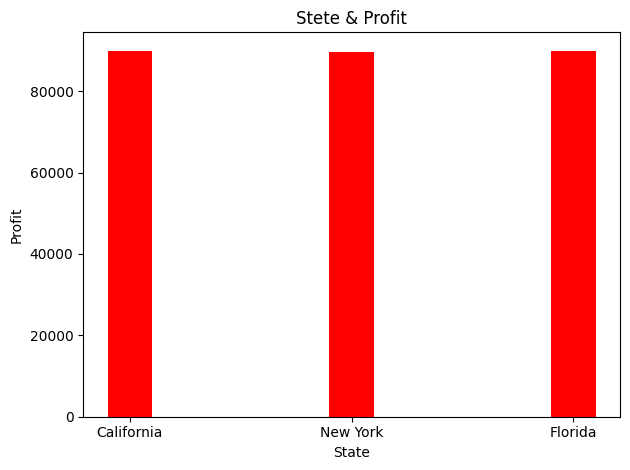

In [47]:
state_bar=plt.bar(ds.State,ds.Profit,color="red",width=0.2, align='center')
plt.title("Stete & Profit")
plt.ylabel("Profit")
plt.xlabel("State")
plt.tight_layout()
plt.show()

# number of companies in each state dont reach 60000 profit

In [40]:
print("->",ds[(ds['Profit'] < 60000) & (ds['State'] == 'California')& (ds['Total Spend']>100000)][['State','Profit','Total Spend']].value_counts().sum(),"is the total number of companies in California makes profit lower than 55000")


print("->",ds[(ds['Profit'] < 60000) & (ds['State'] == 'New York')& (ds['Total Spend']>100000)][['State','Profit','Total Spend']].value_counts().sum(),"is the total number of companies in New York makes profit lower than 55000")


print( "->",ds[(ds['Profit'] < 60000) & (ds['State'] == 'Florida')& (ds['Total Spend']>100000)][['State','Profit','Total Spend']].value_counts().sum(),"is the total number of companies in Florida makes profit lower than 55000")




-> 31 is the total number of companies in California makes profit lower than 55000
-> 27 is the total number of companies in New York makes profit lower than 55000
-> 18 is the total number of companies in Florida makes profit lower than 55000
